In [1]:
!pip install scipy numpy matplotlib seaborn


[notice] A new release of pip is available: 25.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [3]:
import matplotlib.font_manager as fm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib import font_manager
from matplotlib import rcParams
 
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, fftfreq
from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit
import sys
import os
from pathlib import Path

 

In [4]:
from structure_factor import *


## Load data

In [14]:
N = 256
boundary = "periodic"
print_results= "true"
method = "NMG"

dt = "5.50e-06"

outdir=f"/sfs/gpfs/tardis/home/xpz5km/Cahn_Hilliard_Model_HPC/spinodal_decomp/structure_factor_results/{N}_{boundary}_{method}_{dt}"
if Path(outdir).is_dir():
    print("Folder exists")
else:
    os.mkdir(outdir)

plt.rcParams['pdf.use14corefonts'] = True
 
 

Folder exists


In [15]:

print(f"Running analysis: N={N}, boundary={boundary}, method={method}")
 
L = 1
 
# Construct input filename based on parameters
indir = f"/project/g_bme-janeslab/Kevin_PaperBackups/GrovesSM_PLoSComputBiol/Data_and_output/simulation_results/spinodal_decomp_06_2025/out_Julia"
if Path(indir).is_dir():
    print("Folder exists")
else:
    print("Folder does not exist")
phi_filename = f"{method}_Julia_2000_dt_{dt}_Nx_{N}_{boundary}_dtout_1050p_phi.csv"
phi_path = os.path.join(indir, phi_filename)
#  SAV_Julia_20000_dt_5.50e-07_Nx_512_neumann_dtout_1075p_energy
print(f"Loading: {phi_path}")
if not os.path.exists(phi_path):
    print(f"ERROR: File not found: {phi_path}")
    sys.exit(1)
 
phi_raw = np.genfromtxt(phi_path, delimiter=",")
phi_raw = phi_raw.reshape(-1, N, N).transpose(1, 2, 0)
 
print(f"Loaded shape: {phi_raw.shape}")
 

Running analysis: N=256, boundary=periodic, method=NMG
Folder exists
Loading: /project/g_bme-janeslab/Kevin_PaperBackups/GrovesSM_PLoSComputBiol/Data_and_output/simulation_results/spinodal_decomp_06_2025/out_Julia/NMG_Julia_2000_dt_5.50e-06_Nx_256_periodic_dtout_1050p_phi.csv
Loaded shape: (256, 256, 201)


In [16]:
phi_list, times = [], []
 
for i in range(phi_raw.shape[2]):
    phi_list.append(phi_raw[:, :, i])
times = np.arange(phi_raw.shape[2]) * 10.0
 
print(
    f"Generated {len(phi_list)} snapshots over t ∈ [{times[0]:.2f}, {times[-1]:.2f}]"
)
 

Generated 201 snapshots over t ∈ [0.00, 2000.00]


In [ ]:
# Analyze
print("Computing structure factor S(k,t)...")
analyzer = StructureFactorAnalyzer(L=L, N=N)
result = analyzer.analyze_series(phi_list, times=times)
print(
    f"Length scales range: l(t) ∈ [{result['l'].min():.3f}, {result['l'].max():.3f}]"
)
 

Computing structure factor S(k,t)...
Length scales range: l(t) ∈ [0.077, 0.200]


In [ ]:

# %%
# Fit
print("\n[3] Fitting coarsening exponent...")
# Use last 80% of data to avoid transient phase at beginning
t_min = times[int(0.1 * len(times))]
t_max = times[-1]
 
fit = fit_exponent(result['t'], result['l'], t_min=t_min, t_max=t_max)
 
print(f"Exponent (fit):    {fit['exponent']:.6f}")
print(f"Exponent (theory): 0.333333")
print(
    f"Error:             {abs(fit['exponent'] - 1/3) / (1/3) * 100:.2f}%"
)
print(f"Amplitude:         {fit['amplitude']:.6f}")
print(f"R2 quality:        {fit['r2']:.8f}")
print(f"Fit window:        t ∈ [{t_min:.3f}, {t_max:.3f}]")
 


[3] Fitting coarsening exponent...
Exponent (fit):    0.302643
Exponent (theory): 0.333333
Error:             9.21%
Amplitude:         0.015910
R2 quality:        0.81057025
Fit window:        t ∈ [200.000, 2000.000]


In [ ]:

# %%
# Plots
print("\n[4] Generating plots...")
 
fig1, _ = plot_structure_factor_snapshots(result, n_snapshots=4)
fig1.savefig(os.path.join(outdir, 's_k_evolution.png'),
             dpi=150,
             bbox_inches='tight')
print(f"✓ Saved: {outdir}/s_k_evolution.png")
 
fig2, _, _ = plot_coarsening_law(result['t'],
                                 result['l'],
                                 t_min=t_min,
                                 t_max=t_max)
fig2.savefig(os.path.join(outdir, 'coarsening_law.png'),
             dpi=150,
             bbox_inches='tight')
print(f"✓ Saved: {outdir}/coarsening_law.png")
 
fig3, _ = plot_phase_field_samples(phi_list, times=times)
fig3.savefig(os.path.join(outdir, 'phase_field_evolution.png'),
             dpi=150,
             bbox_inches='tight')
print(f"✓ Saved: {outdir}/phase_field_evolution.png")
 
# Save fit results to CSV
fit_results = pd.DataFrame({
    'N': [N],
    'boundary': [boundary],
    'method': [method],
    'exponent': [fit['exponent']],
    'exponent_theory': [1/3],
    'error_percent': [abs(fit['exponent'] - 1/3) / (1/3) * 100],
    'amplitude': [fit['amplitude']],
    'r2': [fit['r2']],
    't_min': [t_min],
    't_max': [t_max]
})
fit_results.to_csv(os.path.join(outdir, 'fit_results.csv'), index=False)
print(f"✓ Saved: {outdir}/fit_results.csv")
 
# Summary
print("\n" + "="*60)
if abs(fit['exponent'] - 1 / 3) < 0.01:
    print("✓ SUCCESS: Exponent is consistent with t^(1/3) LSV scaling!")
elif abs(fit['exponent'] - 1 / 3) < 0.05:
    print("≈ MARGINAL: Exponent is close but shows some deviation.")
    print("  Check transient regime and domain saturation effects.")
else:
    print("✗ FAILURE: Exponent significantly deviates from t^(1/3).")
    print("  Likely issues:")
    print("    - Too much numerical dissipation or coarse grid")
    print("    - Data dominated by transient or saturation regime")
    print("    - Non-conservative dynamics (check model type)")
print("="*60)
 
plt.close('all')


[4] Generating plots...
✓ Saved: /sfs/gpfs/tardis/home/xpz5km/Cahn_Hilliard_Model_HPC/spinodal_decomp/structure_factor_results/256_periodic_NMG_5.50e-06/s_k_evolution.png
✓ Saved: /sfs/gpfs/tardis/home/xpz5km/Cahn_Hilliard_Model_HPC/spinodal_decomp/structure_factor_results/256_periodic_NMG_5.50e-06/coarsening_law.png
✓ Saved: /sfs/gpfs/tardis/home/xpz5km/Cahn_Hilliard_Model_HPC/spinodal_decomp/structure_factor_results/256_periodic_NMG_5.50e-06/phase_field_evolution.png
✓ Saved: /sfs/gpfs/tardis/home/xpz5km/Cahn_Hilliard_Model_HPC/spinodal_decomp/structure_factor_results/256_periodic_NMG_5.50e-06/fit_results.csv

≈ MARGINAL: Exponent is close but shows some deviation.
  Check transient regime and domain saturation effects.


## Run Structure factor analysis as function

In [5]:
def load_data(method, dt, N, boundary, timesteps, language, ic = "50p"):
    # Construct input filename based on parameters
    # Adjust path and naming convention to match your actual files
    indir = f"/project/g_bme-janeslab/Kevin_PaperBackups/GrovesSM_PLoSComputBiol/Data_and_output/simulation_results/spinodal_decomp_06_2025/out_Julia"
    phi_filename = f"{method}_{language}_{timesteps}_dt_{dt}_Nx_{N}_{boundary}_dtout_10{ic}_phi.csv"
    phi_path = os.path.join(indir, phi_filename)
    #  SAV_Julia_20000_dt_5.50e-07_Nx_512_neumann_dtout_1075p_energy
    print(f"Loading: {phi_path}")
    if not os.path.exists(phi_path):
        print(f"ERROR: File not found: {phi_path}")
        sys.exit(1)
     
    phi_raw = np.genfromtxt(phi_path, delimiter=",")
    phi_raw = phi_raw.reshape(-1, N, N).transpose(1, 2, 0)
     
    print(f"Loaded shape: {phi_raw.shape}")
    phi_list, times = [], []
 
    for i in range(phi_raw.shape[2]):
        phi_list.append(phi_raw[:, :, i])
    times = np.arange(phi_raw.shape[2]) * 10.0
     
    print(
        f"Generated {len(phi_list)} snapshots over t ∈ [{times[0]:.2f}, {times[-1]:.2f}]"
    )
    return phi_list, times
    
def run_sf_analysis(phi_list, times, method, dt, N, boundary, timesteps, language, t_min_perc = 0, t_max_perc =1, suffix = ""):
    brcd = np.random.randint(1000)
    outdir=f"/sfs/gpfs/tardis/home/xpz5km/Cahn_Hilliard_Model_HPC/spinodal_decomp/structure_factor_results/{N}_{boundary}_{method}_{dt}_{language}_{timesteps}{suffix}"
    if Path(outdir).is_dir():
        print("Folder exists")
    else:
        os.mkdir(outdir)
    
    plt.rcParams['pdf.use14corefonts'] = True
    L = 1
     
    
    # Analyze
    print("Computing structure factor S(k,t)...")
    analyzer = StructureFactorAnalyzer(L=L, N=N)
    result = analyzer.analyze_series(phi_list, times=times)
    print(
        f"Length scales range: l(t) ∈ [{result['l'].min():.3f}, {result['l'].max():.3f}]"
    )
    # %%
    # Fit
    print("\n[3] Fitting coarsening exponent...")
    # Use last 90% of data to avoid transient phase at beginning
    t_min = times[int(t_min_perc * len(times))]
    t_max = times[int(t_max_perc * len(times)-1)]
     
    fit = fit_exponent(result['t'], result['l'], t_min=t_min, t_max=t_max)
     
    print(f"Exponent (fit):    {fit['exponent']:.6f}")
    print(f"Exponent (theory): 0.333333")
    print(
        f"Error:             {abs(fit['exponent'] - 1/3) / (1/3) * 100:.2f}%"
    )
    print(f"Amplitude:         {fit['amplitude']:.6f}")
    print(f"R2 quality:        {fit['r2']:.8f}")
    print(f"Fit window:        t ∈ [{t_min:.3f}, {t_max:.3f}]")
        
    # %%
    # Plots
    print("\n[4] Generating plots...")
     
    fig1, _ = plot_structure_factor_snapshots(result, n_snapshots=4)
    fig1.savefig(os.path.join(outdir, f's_k_evolution_{brcd}.png'),
                 dpi=150,
                 bbox_inches='tight')
    print(f"✓ Saved: {outdir}/s_k_evolution.png")
     
    fig2, _, _, scale, A_err = plot_coarsening_law(result['t'],
                                     result['l'],
                                     t_min=t_min,
                                     t_max=t_max)
    fig2.savefig(os.path.join(outdir, f'coarsening_law_{brcd}.png'),
                 dpi=150,
                 bbox_inches='tight')
    print(f"✓ Saved: {outdir}/coarsening_law.png")
     
    fig3, _ = plot_phase_field_samples(phi_list, times=times)
    fig3.savefig(os.path.join(outdir, f'phase_field_evolution_{brcd}.png'),
                 dpi=150,
                 bbox_inches='tight')
    print(f"✓ Saved: {outdir}/phase_field_evolution.png")
     
    # Save fit results to CSV
    fit_results = pd.DataFrame({
        'N': [N],
        'boundary': [boundary],
        'method': [method],
        'exponent': [fit['exponent']],
        'exponent_theory': [1/3],
        'error_percent': [abs(fit['exponent'] - 1/3) / (1/3) * 100],
        'amplitude': [fit['amplitude']],
        'r2': [fit['r2']],
        't_min': [t_min],
        't_max': [t_max],
        'scale_theory':scale,
        'scale_err_theory':A_err,
        "brcd":brcd
    })
    filepath = os.path.join(outdir, 'fit_results.csv')
    if os.path.exists(filepath):
        print("file exists; appending to file.")
        fit_results.to_csv(filepath, mode='a', header=False, index=False)
    else:
        fit_results.to_csv(filepath, index=False)
    print(f"✓ Saved: {outdir}/fit_results.csv")
     
    # Summary
    print("\n" + "="*60)
    if abs(fit['exponent'] - 1 / 3) < 0.01:
        print("✓ SUCCESS: Exponent is consistent with t^(1/3) LSV scaling!")
    elif abs(fit['exponent'] - 1 / 3) < 0.05:
        print("≈ MARGINAL: Exponent is close but shows some deviation.")
        print("  Check transient regime and domain saturation effects.")
    else:
        print("✗ FAILURE: Exponent significantly deviates from t^(1/3).")
        print("  Likely issues:")
        print("    - Too much numerical dissipation or coarse grid")
        print("    - Data dominated by transient or saturation regime")
        print("    - Non-conservative dynamics (check model type)")
    print("="*60)
     
    plt.close('all')
         

In [6]:
dt = "5.50e-06"
boundary = "periodic"
phi_list_512, times_512 = load_data('SAV', dt, 512, boundary, 2000, "Julia")


Loading: /project/g_bme-janeslab/Kevin_PaperBackups/GrovesSM_PLoSComputBiol/Data_and_output/simulation_results/spinodal_decomp_06_2025/out_Julia/SAV_Julia_2000_dt_5.50e-06_Nx_512_periodic_dtout_1050p_phi.csv
Loaded shape: (512, 512, 201)
Generated 201 snapshots over t ∈ [0.00, 2000.00]


In [7]:
run_sf_analysis(phi_list_512, times_512, 'SAV', dt, 512, boundary, 2000, "Julia", t_min_perc=0.1)

Folder exists
Computing structure factor S(k,t)...
Length scales range: l(t) ∈ [0.036, 0.143]

[3] Fitting coarsening exponent...
Exponent (fit):    0.369058
Exponent (theory): 0.333333
Error:             10.72%
Amplitude:         0.007670
R2 quality:        0.90513015
Fit window:        t ∈ [200.000, 2000.000]

[4] Generating plots...
✓ Saved: /sfs/gpfs/tardis/home/xpz5km/Cahn_Hilliard_Model_HPC/spinodal_decomp/structure_factor_results/512_periodic_SAV_5.50e-06_Julia_2000/s_k_evolution.png
Scale and error on amplitude of A*t^1/3:  0.009927656528084734 5.8884120834390034e-05
✓ Saved: /sfs/gpfs/tardis/home/xpz5km/Cahn_Hilliard_Model_HPC/spinodal_decomp/structure_factor_results/512_periodic_SAV_5.50e-06_Julia_2000/coarsening_law.png
✓ Saved: /sfs/gpfs/tardis/home/xpz5km/Cahn_Hilliard_Model_HPC/spinodal_decomp/structure_factor_results/512_periodic_SAV_5.50e-06_Julia_2000/phase_field_evolution.png
file exists; appending to file.
✓ Saved: /sfs/gpfs/tardis/home/xpz5km/Cahn_Hilliard_Model_HPC

In [ ]:
run_sf_analysis(phi_list_512, times_512, 'SAV', dt, 512, boundary, 2000, "Julia", t_min_perc=0.0)

Folder exists
Computing structure factor S(k,t)...
Length scales range: l(t) ∈ [0.036, 0.143]

[3] Fitting coarsening exponent...
Exponent (fit):    0.310194
Exponent (theory): 0.333333
Error:             6.94%
Amplitude:         0.011541
R2 quality:        0.92516941
Fit window:        t ∈ [0.000, 2000.000]

[4] Generating plots...
✓ Saved: /sfs/gpfs/tardis/home/xpz5km/Cahn_Hilliard_Model_HPC/spinodal_decomp/structure_factor_results/512_periodic_SAV_5.50e-06_Julia_2000/s_k_evolution.png
Scale and error on amplitude of A*t^1/3:  0.00992765652795013 7.068783583164089e-05
✓ Saved: /sfs/gpfs/tardis/home/xpz5km/Cahn_Hilliard_Model_HPC/spinodal_decomp/structure_factor_results/512_periodic_SAV_5.50e-06_Julia_2000/coarsening_law.png
✓ Saved: /sfs/gpfs/tardis/home/xpz5km/Cahn_Hilliard_Model_HPC/spinodal_decomp/structure_factor_results/512_periodic_SAV_5.50e-06_Julia_2000/phase_field_evolution.png
file exists; appending to file.
✓ Saved: /sfs/gpfs/tardis/home/xpz5km/Cahn_Hilliard_Model_HPC/spin

In [ ]:
phi_list_256, times_256 = load_data('NMG', dt, 256, boundary, 2000, "Julia")
run_sf_analysis(phi_list_256, times_256, 'NMG', dt, 256, boundary, 2000, "Julia", t_min_perc=0.0)

In [ ]:
run_sf_analysis(phi_list_256, times_256, 'NMG', dt, 256, boundary, 2000, "Julia", t_min_perc=0.1)

In [ ]:
phi_list_128, times_128 = load_data('NMG', dt, 128, boundary, 2000, "Julia")
run_sf_analysis(phi_list_128, times_128, 'NMG', dt, 128, boundary, 2000, "Julia", t_min_perc=0.1)

In [ ]:
run_sf_analysis(phi_list_128, times_128, 'NMG', dt, 128, boundary, 2000, "Julia", t_min_perc=0.0)

In [ ]:
dt = "5.50e-07"
phi_list, times = load_data('NMG', dt, 256, boundary, 20000, "Julia")
run_sf_analysis(phi_list, times,'NMG', dt, 256, boundary, 20000, "Julia")

## Plots for Figure S2: gridsize = 512, dt = 5.5e-6, neumann and periodic, SAV and NMG

### Periodic and neumann

In [31]:
dt = "5.50e-06"
boundary = "periodic"
N = 512
phi_list_NMG, times_NMG = load_data('NMG', dt, N, boundary, 2000, "Julia")


Loading: /project/g_bme-janeslab/Kevin_PaperBackups/GrovesSM_PLoSComputBiol/Data_and_output/simulation_results/spinodal_decomp_06_2025/out_Julia/NMG_Julia_2000_dt_5.50e-06_Nx_512_periodic_dtout_1050p_phi.csv
Loaded shape: (512, 512, 201)
Generated 201 snapshots over t ∈ [0.00, 2000.00]


In [32]:
phi_list_SAV, times_SAV = load_data('SAV', dt, N, boundary, 2000, "Julia")


Loading: /project/g_bme-janeslab/Kevin_PaperBackups/GrovesSM_PLoSComputBiol/Data_and_output/simulation_results/spinodal_decomp_06_2025/out_Julia/SAV_Julia_2000_dt_5.50e-06_Nx_512_periodic_dtout_1050p_phi.csv
Loaded shape: (512, 512, 201)
Generated 201 snapshots over t ∈ [0.00, 2000.00]


In [33]:
outdir=f"/sfs/gpfs/tardis/home/xpz5km/Cahn_Hilliard_Model_HPC/spinodal_decomp/structure_factor_results/{N}_{boundary}_{dt}_Julia_2000"

L = 1
 
# Analyze
print("Computing structure factor S(k,t)...")
analyzer = StructureFactorAnalyzer(L=L, N=N)
result_NMG = analyzer.analyze_series(phi_list_NMG, times=times_NMG)
print(
    f"Length scales range: l(t) ∈ [{result_NMG['l'].min():.3f}, {result_NMG['l'].max():.3f}]"
)
result_SAV = analyzer.analyze_series(phi_list_SAV, times=times_SAV)
print(
    f"Length scales range: l(t) ∈ [{result_SAV['l'].min():.3f}, {result_SAV['l'].max():.3f}]"
)

Computing structure factor S(k,t)...
Length scales range: l(t) ∈ [0.036, 0.143]
Length scales range: l(t) ∈ [0.036, 0.143]


In [34]:
# Fit
print("\n[3] Fitting coarsening exponent...")
t_min_perc = 0
t_max_perc = 1
# Use last 90% of data to avoid transient phase at beginning
t_min = times_NMG[int(t_min_perc * len(times_NMG))]
t_max = times_NMG[int(t_max_perc * len(times_NMG)-1)]
 
fit_NMG = fit_exponent(result_NMG['t'], result_NMG['l'], t_min=t_min, t_max=t_max)
 


[3] Fitting coarsening exponent...


In [35]:
 
fit_SAV = fit_exponent(result_SAV['t'], result_SAV['l'], t_min=t_min, t_max=t_max)

In [36]:
scale, A_err = fit_theory_amplitude(result_NMG['t'], result_NMG['l'])
print("Scale and error on amplitude of A*t^1/3: ", scale, A_err)
# scale = np.median(l) / (np.median(t) ** (1/3))
l_theory = scale * (fit_NMG["t_fit"] ** (1/3))
fit_NMG["l_theory"] = l_theory

ss_res = np.sum((fit_NMG["l_fit"] - fit_NMG["l_theory"]) ** 2)
ss_tot = np.sum((fit_NMG["l_fit"] - np.mean(fit_NMG["l_fit"])) ** 2)
r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
fit_NMG['theory_r2'] = r2

scale, A_err = fit_theory_amplitude(result_SAV['t'], result_SAV['l'])
print("Scale and error on amplitude of A*t^1/3: ", scale, A_err)
# scale = np.median(l) / (np.median(t) ** (1/3))
l_theory = scale * (fit_SAV["t_fit"] ** (1/3))
fit_SAV["l_theory"] = l_theory

ss_res = np.sum((fit_SAV["l_fit"] - fit_SAV["l_theory"]) ** 2)
ss_tot = np.sum((fit_SAV["l_fit"] - np.mean(fit_SAV["l_fit"])) ** 2)
r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
fit_SAV['theory_r2'] = r2

Scale and error on amplitude of A*t^1/3:  0.010090465743644458 6.599312494613183e-05
Scale and error on amplitude of A*t^1/3:  0.009927656528084734 5.8884120834390034e-05


In [37]:
fit_SAV['theory_r2']

np.float64(0.9019222253076526)

In [38]:
fit_NMG["l_pred"] = 10 ** fit_NMG['log10_l_pred']

In [39]:
fit_SAV["l_pred"] = 10 ** fit_SAV['log10_l_pred']

In [40]:
fit_NMG.keys()

dict_keys(['exponent', 'amplitude', 'r2', 't_fit', 'l_fit', 'log10_t_fit', 'log10_l_fit', 'log10_l_pred', 'l_theory', 'theory_r2', 'l_pred'])

In [41]:
result_NMG.keys()

dict_keys(['t', 'k', 'S_k', 'l', 'k_peak'])

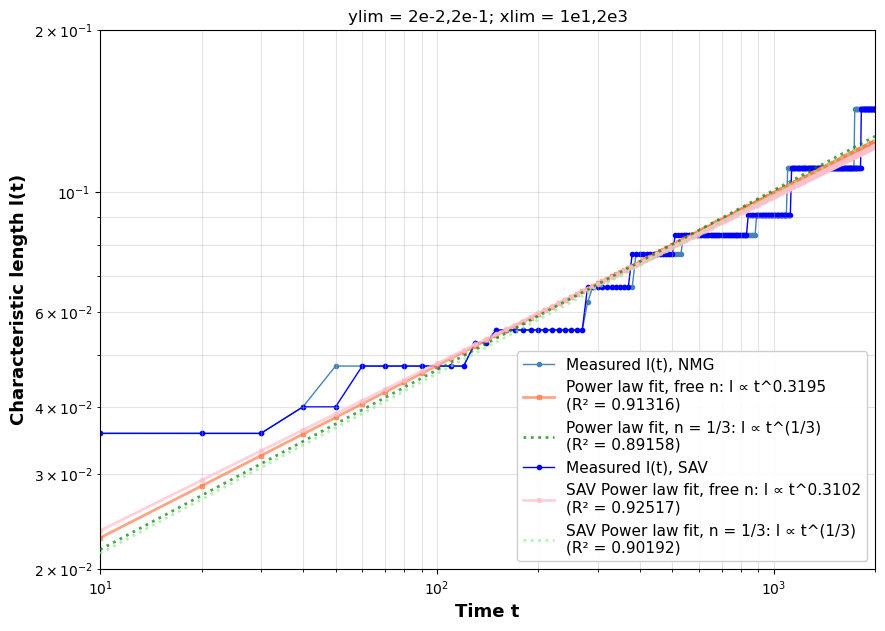

In [42]:


fig, ax = plt.subplots(figsize=(10, 7))

# NMG data
ax.plot(result_NMG['t'], result_NMG["l"], 'o-', color='steelblue', linewidth=1, markersize=3,
          label='Measured l(t), NMG', zorder=1)

ax.plot(fit_NMG["t_fit"], fit_NMG["l_pred"], 's-', color='coral', linewidth=2, markersize=3,alpha=0.7,
          label=f"Power law fit, free n: l ∝ t^{fit_NMG["exponent"]:.4f}\n(R² = {fit_NMG['r2']:.5f})", zorder=2)

# fit best scale for theory
ax.plot(fit_NMG["t_fit"], fit_NMG["l_theory"], ':', color='green', linewidth=2, alpha=0.7,
          label=f'Power law fit, n = 1/3: l ∝ t^(1/3)\n(R² = {fit_NMG['theory_r2']:.5f})', zorder=3)

# SAV data
ax.plot(result_SAV['t'], result_SAV["l"], 'o-', color='blue', linewidth=1, markersize=3,
          label='Measured l(t), SAV', zorder=1)

ax.plot(fit_SAV["t_fit"], fit_SAV["l_pred"], 'o-', color='pink', linewidth=2, markersize=3,alpha=0.7,
          label=f"SAV Power law fit, free n: l ∝ t^{fit_SAV["exponent"]:.4f}\n(R² = {fit_SAV['r2']:.5f})", zorder=2)

# fit best scale for theory
ax.plot(fit_SAV["t_fit"], fit_SAV["l_theory"], ':', color='lightgreen', linewidth=2, alpha=0.7,
          label=f'SAV Power law fit, n = 1/3: l ∝ t^(1/3)\n(R² = {fit_SAV['theory_r2']:.5f})', zorder=3)

ax.set_xlabel('Time t', fontsize=13, fontweight='bold')
ax.set_ylabel('Characteristic length l(t)', fontsize=13, fontweight='bold')
ax.set_title('Power law between char. length scale and time: l ∝ t^n',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right', framealpha=0.95)
ax.grid(True, alpha=0.35, which='both')
#set log-log ax
plt.loglog()
# # Add annotations
# textstr = f"Measured exponent: {fit_NMG["exponent"]:.4f}\nLSV theory: 0.3333\nDeviation: {abs(exponent-1/3)/(1/3)*100:.1f}%"
# ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=11,
#         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.ylim(2e-2,2e-1)
plt.xlim(1e1,2e3)
plt.title("ylim = 2e-2,2e-1; xlim = 1e1,2e3")
plt.savefig(f"../structure_factor_results/{boundary}_512_5.5e-06_julia_2000_log_newaxes.pdf")
plt.show()